# RQ1 — How Does Southeast Asian Broadband Measure Up? (Ookla, Fixed + Mobile, 9 Countries)

**Question:** Ookla Speedtest Global Index ranks Thailand fixed broadband #13 worldwide (looks good),
but ETDA / consumer-complaint surveys report frequent slow/dropped connections (looks bad) — the
starting puzzle for this study (see paper Introduction). Rather than answer that in isolation,
this notebook puts Thailand alongside 8 Southeast Asian neighbors on the same rubric: **concrete
application-requirement thresholds**, following Lübben & Misfeld (2022), *"Exploring the
Measurement Lab Open Dataset for Internet Performance Evaluation: The German Internet Landscape"*
(`docs/02-ndt7-mlab/lubben-misfeld-2022-mlab-german-internet-landscape.pdf`, Table 5):

| Application | Data rate | Latency |
|---|---|---|
| Voice | 64 kbps | 200 ms |
| Video streaming (HD) | 5 Mbps | few seconds |
| Video streaming (UHD) | 25 Mbps | few seconds |
| Cloud gaming | 44 Mbps | 25 ms |

Voice's 64 kbps requirement is trivially met by any broadband connection, so it collapses to a
latency-only check here.

**Scope:** Ookla fixed broadband, followed by a mirrored mobile section (added 2026-07-30). All 9
countries in this study's exports (Thailand, Vietnam, Philippines, Singapore, Cambodia, Laos,
Malaysia, Myanmar, and Indonesia — added 2026-07-30 as this notebook's 9th country) are compared
on equal footing — no country is treated as the reference case, all 9 get the same charts and the
same analytical depth, on both fixed and mobile.

**Methodology note (limitation to carry into the paper):** each row in these export CSVs is
already a **province × quarter average** (`avg_d_mbps`, `avg_lat_ms_wt`), not a raw per-test
record. "% passing a threshold" below is therefore a **test-count-weighted share of
province-quarters whose average clears the bar**, not a literal % of individual speed tests —
a coarser proxy forced by the data's aggregation level. Weighting by `total_tests` (rather than
a flat per-province-quarter average) at least prevents low-sample provinces from swaying the
national figure as much as high-sample ones.

**2026-07-30 note:** Indonesia's addition here changes the actual reported Results numbers below
(not just adding a parallel section) — `docs/paper_draft.md` §3.1/§3.2 still describe the
previous 8-country numbers and need porting once these are reviewed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

EXPORTS = Path('../../data/exports')

COUNTRIES = {
    'Thailand':    'ookla_province_quarterly.csv',
    'Vietnam':     'ookla_vietnam_province_quarterly.csv',
    'Philippines': 'ookla_philippines_province_quarterly.csv',
    'Singapore':   'ookla_singapore_province_quarterly.csv',
    'Cambodia':    'ookla_cambodia_province_quarterly.csv',
    'Laos':        'ookla_laos_province_quarterly.csv',
    'Malaysia':    'ookla_malaysia_province_quarterly.csv',
    'Myanmar':     'ookla_myanmar_province_quarterly.csv',
    'Indonesia':   'ookla_indonesia_province_quarterly.csv',  # 9th country, added 2026-07-30
}

# one consistent color per country, used across every chart in this notebook -- no country
# singled out or highlighted differently from the others
COUNTRY_COLORS = {c: plt.cm.tab10(i) for i, c in enumerate(COUNTRIES)}

frames = []
for country, fname in COUNTRIES.items():
    df = pd.read_csv(EXPORTS / fname)
    df['country'] = country
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
all_df.shape


(3222, 16)

### Data quality check — `is_reliable` already filters at export time

In [2]:
print(all_df.groupby('country')['is_reliable'].value_counts(dropna=False))
print()
print(all_df.groupby('country').size().rename('province_quarter_rows'))

country      is_reliable
Cambodia     True           300
Indonesia    True           408
Laos         True           216
Malaysia     True           192
Myanmar      True           150
Philippines  True           204
Singapore    True            60
Thailand     True           924
Vietnam      True           768
Name: count, dtype: int64

country
Cambodia       300
Indonesia      408
Laos           216
Malaysia       192
Myanmar        150
Philippines    204
Singapore       60
Thailand       924
Vietnam        768
Name: province_quarter_rows, dtype: int64


All rows are `is_reliable == True` in every country's export — the unreliable rows were
already dropped upstream, so no further filtering is needed here.

### Threshold indicators

In [3]:
THRESH = {
    'HD (5 Mbps)':          lambda d: d['avg_d_mbps'] >= 5,
    'UHD (25 Mbps)':        lambda d: d['avg_d_mbps'] >= 25,
    'Cloud gaming (44 Mbps + <=25ms)': lambda d: (d['avg_d_mbps'] >= 44) & (d['avg_lat_ms_wt'] <= 25),
    'Voice latency (<=200ms)': lambda d: d['avg_lat_ms_wt'] <= 200,
}

for label, fn in THRESH.items():
    all_df[label] = fn(all_df)

all_df[list(THRESH.keys())].mean().round(3)

HD (5 Mbps)                        1.000
UHD (25 Mbps)                      0.946
Cloud gaming (44 Mbps + <=25ms)    0.746
Voice latency (<=200ms)            0.999
dtype: float64

### National comparison — test-weighted % of province-quarters clearing each threshold

In [4]:
def weighted_pass_rate(df, col):
    return np.average(df[col], weights=df['total_tests'])

rows = []
for country in COUNTRIES:
    sub = all_df[all_df['country'] == country]
    row = {'country': country, 'n_tests_total': int(sub['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(sub, label)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('country')
summary_pct = (summary[list(THRESH.keys())] * 100).round(1)
summary_pct['n_tests_total'] = summary['n_tests_total']
summary_pct.sort_values('UHD (25 Mbps)', ascending=False)

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_tests_total
country,,,,,
Thailand,100.0,100.0,99.5,100.0,20769822
Vietnam,100.0,100.0,100.0,100.0,25884919
Philippines,100.0,100.0,92.6,100.0,48847570
Singapore,100.0,100.0,100.0,100.0,4473165
Malaysia,100.0,100.0,97.6,100.0,15663189
Laos,100.0,99.4,64.2,100.0,373145
Cambodia,100.0,97.6,64.9,100.0,2383073
Indonesia,100.0,88.1,35.6,100.0,54151251
Myanmar,100.0,22.1,0.0,98.2,1750990


### Chart — all 9 countries, equal footing


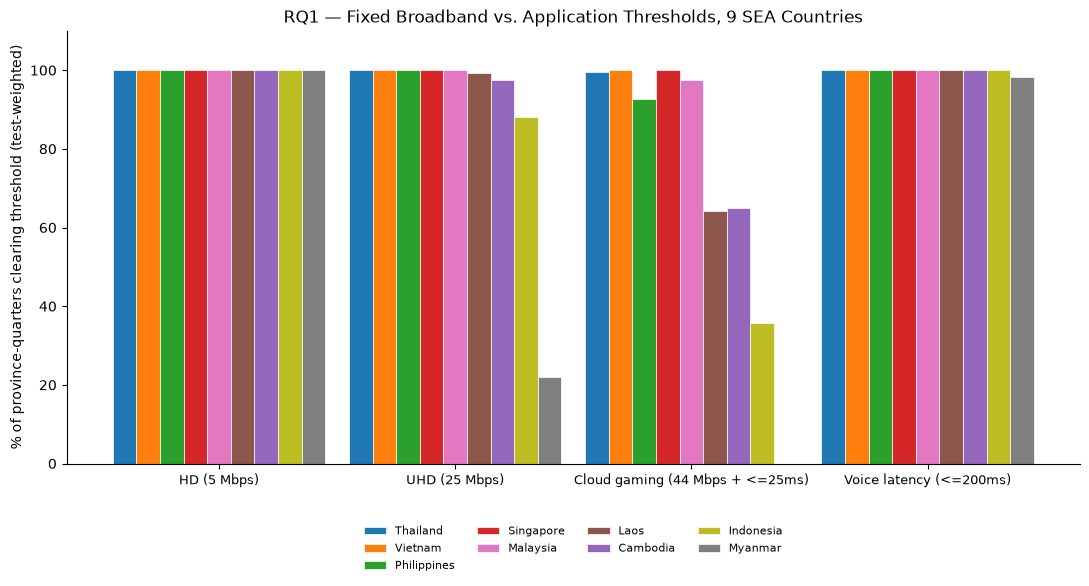

In [5]:
metrics = list(THRESH.keys())
countries_order = summary_pct.sort_values('UHD (25 Mbps)', ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metrics))
width = 0.1

for i, country in enumerate(countries_order):
    vals = summary_pct.loc[country, metrics].values
    ax.bar(x + i * width, vals, width, label=country, color=COUNTRY_COLORS[country],
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width * (len(countries_order) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylabel('% of province-quarters clearing threshold (test-weighted)')
ax.set_ylim(0, 110)
ax.set_title('RQ1 — Fixed Broadband vs. Application Thresholds, 9 SEA Countries')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Where the real threshold failures are — all 9 countries

HD (5 Mbps) is a non-issue everywhere, and UHD (25 Mbps) is trivial for 5 of 9 countries
(Thailand, Vietnam, Philippines, Singapore, Malaysia all at 100%) — the one threshold with
substantial cross-country variance is **cloud gaming (44 Mbps + <=25ms)**: 819 of 3,222
province-quarters (25.4%) fail it SEA-wide, and the failures are concentrated in **7 of the 9
countries** — only Vietnam and Singapore clear it at 100%.


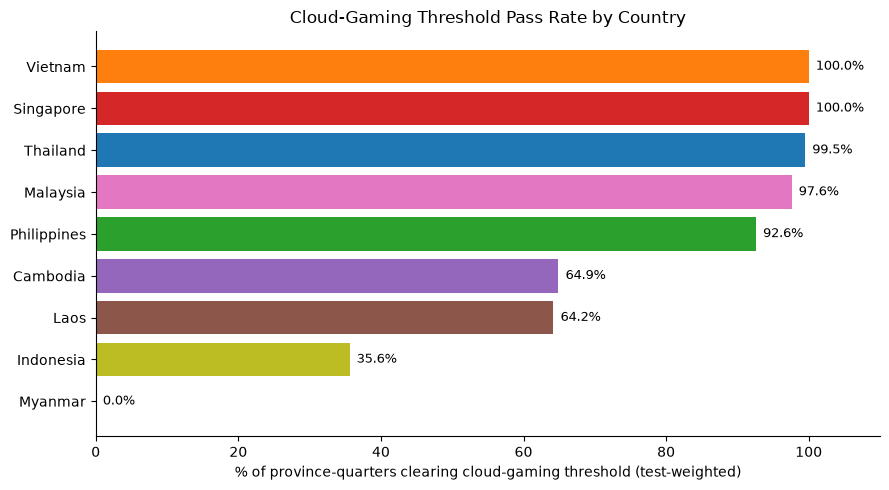

In [6]:
cg_order = summary_pct.sort_values('Cloud gaming (44 Mbps + <=25ms)', ascending=True).index.tolist()
vals = summary_pct.loc[cg_order, 'Cloud gaming (44 Mbps + <=25ms)'].values

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cg_order, vals, color=[COUNTRY_COLORS[c] for c in cg_order])
for bar, val in zip(bars, vals):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 110)
ax.set_xlabel('% of province-quarters clearing cloud-gaming threshold (test-weighted)')
ax.set_title('Cloud-Gaming Threshold Pass Rate by Country')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Worst provinces, across every country with a cloud-gaming failure

Province-level detail for the 71 provinces (across Cambodia, Laos, Malaysia, Myanmar,
Philippines, and Thailand) with at least one quarter failing the cloud-gaming threshold —
top 15 by number of failing quarters (out of 12 possible), colored by country.

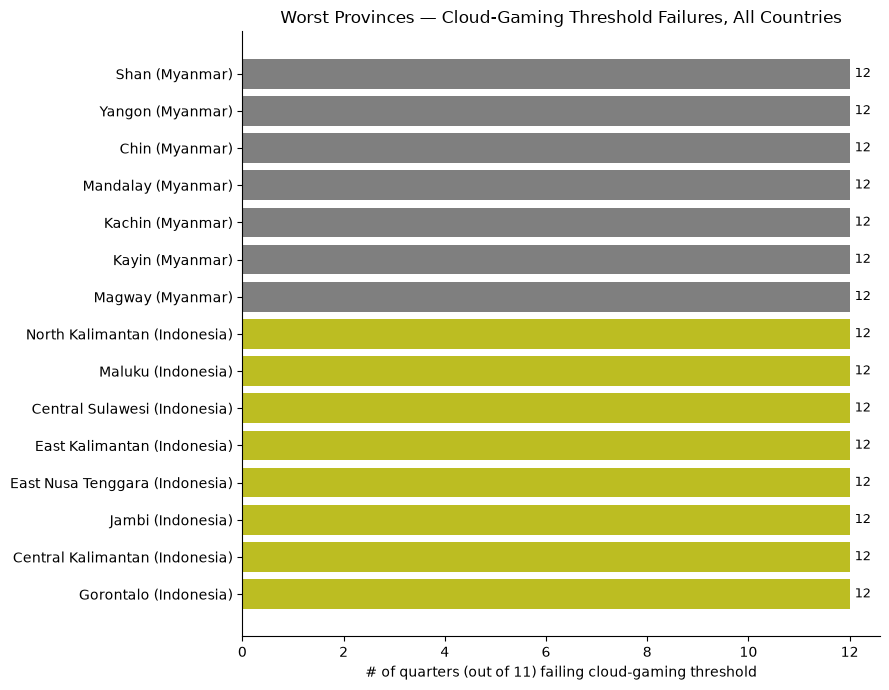

In [7]:
all_df['cg_pass'] = (all_df['avg_d_mbps'] >= 44) & (all_df['avg_lat_ms_wt'] <= 25)
cg_fail = all_df[~all_df['cg_pass']]
by_prov = (
    cg_fail.groupby(['country', 'province']).size().rename('n_fail_qtrs')
    .reset_index().sort_values('n_fail_qtrs', ascending=False).head(15)
    .sort_values('n_fail_qtrs')
)

fig, ax = plt.subplots(figsize=(9, 7))
labels = by_prov['province'] + ' (' + by_prov['country'] + ')'
bars = ax.barh(labels, by_prov['n_fail_qtrs'], color=[COUNTRY_COLORS[c] for c in by_prov['country']])
for bar, val in zip(bars, by_prov['n_fail_qtrs']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2, str(val), va='center', fontsize=9)
ax.set_xlabel('# of quarters (out of 11) failing cloud-gaming threshold')
ax.set_title('Worst Provinces — Cloud-Gaming Threshold Failures, All Countries')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### RQ1.2 — Capital City Comparison (all 9 countries)

Same test-weighted threshold pass rates as above, filtered to each country's capital-city
province only. Capital province used per country:

| Country | Capital used | Note |
|---|---|---|
| Thailand | Bangkok Metropolis | actual capital |
| Vietnam | Hà Nội | actual capital (not Ho Chi Minh City, which is bigger but not the capital) |
| Philippines | NCR | Metro Manila region, contains the capital city |
| Singapore | Central Region | city-state has no separate capital province in this export — Central Region (the CBD) used as the closest proxy |
| Cambodia | Phnom Penh | actual capital |
| Laos | Vientiane Capital | actual capital (distinct from Vientiane province, which is a separate row) |
| Malaysia | Kuala Lumpur | historical/legislative capital (Putrajaya, the newer administrative capital, isn't tracked as its own province in this export) |
| Myanmar | Yangon | **not the actual capital** — Naypyidaw isn't a tracked province in this dataset at all. Yangon (former capital, largest city) used as the closest available proxy. Data-availability limitation, not a scope choice — see [[project_scope_sea_equal]] pattern. |
| Indonesia | Jakarta | actual capital, added 2026-07-30 |


In [8]:
CAPITALS = {
    'Thailand':    'Bangkok Metropolis',
    'Vietnam':     'Hà Nội',
    'Philippines': 'NCR',
    'Singapore':   'Central Region',
    'Cambodia':    'Phnom Penh',
    'Laos':        'Vientiane Capital',
    'Malaysia':    'Kuala Lumpur',
    'Myanmar':     'Yangon',
    'Indonesia':   'Jakarta',
}

cap_mask = all_df.apply(lambda r: r['province'] == CAPITALS.get(r['country']), axis=1)
cap_df = all_df[cap_mask].copy()
cap_df.groupby('country')['province'].unique()

country
Cambodia               [Phnom Penh]
Indonesia                 [Jakarta]
Laos            [Vientiane Capital]
Malaysia             [Kuala Lumpur]
Myanmar                    [Yangon]
Philippines                   [NCR]
Singapore          [Central Region]
Thailand       [Bangkok Metropolis]
Vietnam                    [Hà Nội]
Name: province, dtype: object

In [9]:
cap_rows = []
for country in COUNTRIES:
    sub = cap_df[cap_df['country'] == country]
    row = {'country': country, 'n_tests_total': int(sub['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(sub, label)
    cap_rows.append(row)

cap_summary = pd.DataFrame(cap_rows).set_index('country')
cap_pct = (cap_summary[list(THRESH.keys())] * 100).round(1)
cap_pct['n_tests_total'] = cap_summary['n_tests_total']
cap_pct.sort_values('Cloud gaming (44 Mbps + <=25ms)', ascending=False)

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_tests_total
country,,,,,
Thailand,100.0,100.0,100.0,100.0,5811354
Vietnam,100.0,100.0,100.0,100.0,4690572
Philippines,100.0,100.0,100.0,100.0,13690552
Singapore,100.0,100.0,100.0,100.0,1428002
Malaysia,100.0,100.0,100.0,100.0,2129023
Indonesia,100.0,100.0,100.0,100.0,5696075
Laos,100.0,100.0,77.6,100.0,191022
Cambodia,100.0,100.0,66.8,100.0,1232812
Myanmar,100.0,3.2,0.0,100.0,829946


### Chart — capital cities only, same metrics as the national comparison above

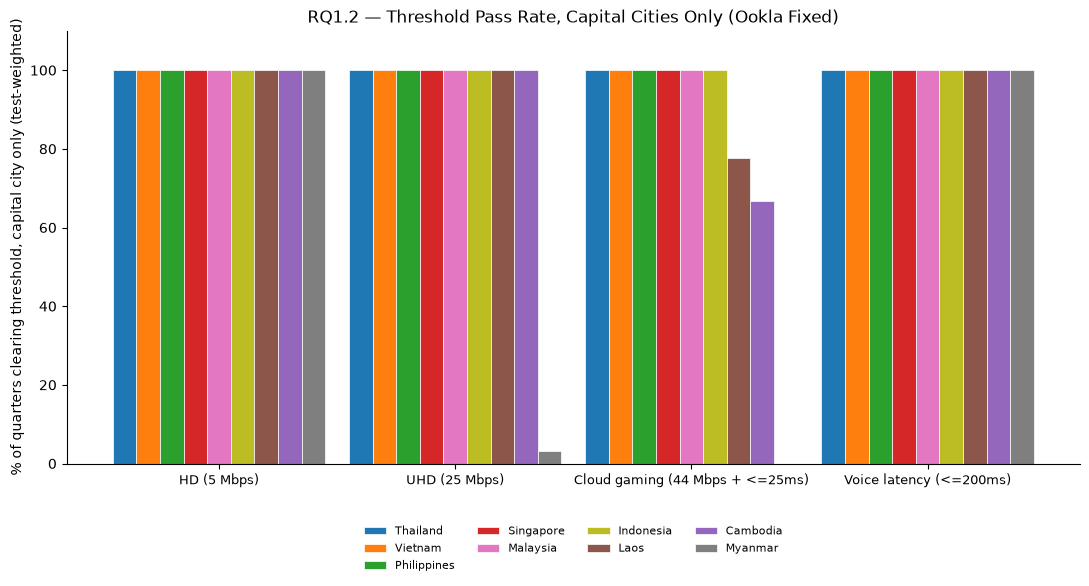

In [10]:
cap_countries_order = cap_pct.sort_values('Cloud gaming (44 Mbps + <=25ms)', ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metrics))
width = 0.1

for i, country in enumerate(cap_countries_order):
    vals = cap_pct.loc[country, metrics].values
    ax.bar(x + i * width, vals, width, label=country, color=COUNTRY_COLORS[country],
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width * (len(cap_countries_order) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylabel('% of quarters clearing threshold, capital city only (test-weighted)')
ax.set_ylim(0, 110)
ax.set_title('RQ1.2 — Threshold Pass Rate, Capital Cities Only (Ookla Fixed)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Chart — capital vs. rest-of-country gap (median download speed)

Does living in the capital actually buy you a faster connection? Compares each capital's
median `avg_d_mbps` against that country's all-province median.

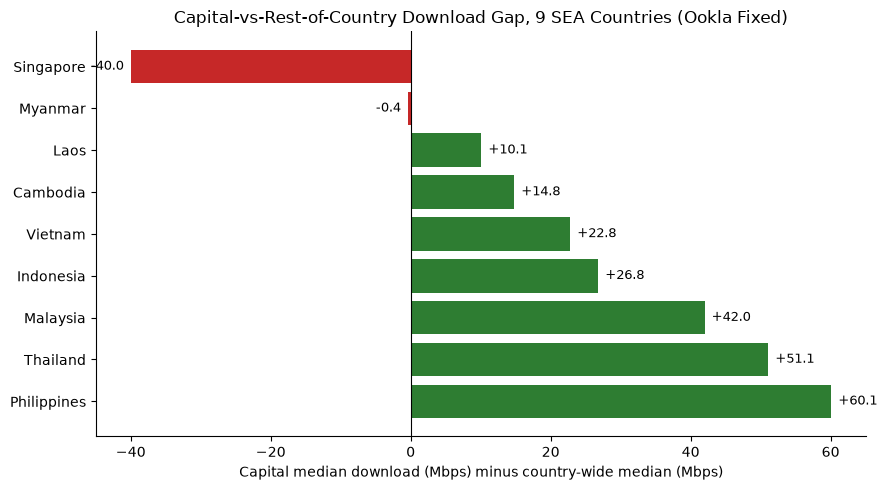

In [11]:
nat_median = all_df.groupby('country')['avg_d_mbps'].median()
cap_median = cap_df.groupby('country')['avg_d_mbps'].median()
gap = (cap_median - nat_median).round(1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2E7D32' if v >= 0 else '#C62828' for v in gap.values]
bars = ax.barh(gap.index, gap.values, color=colors)
for bar, val in zip(bars, gap.values):
    offset = 1 if val >= 0 else -1
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2, f'{val:+.1f}', va='center', ha=ha, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Capital median download (Mbps) minus country-wide median (Mbps)')
ax.set_title('Capital-vs-Rest-of-Country Download Gap, 9 SEA Countries (Ookla Fixed)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Key Findings (RQ1, fixed broadband only)

- **HD (5 Mbps) is a non-issue anywhere** — all 9 SEA countries clear it at 100%, every
  province, every quarter. Ookla's "#13 worldwide, fixed broadband is good" framing (and the
  equivalent framing for any of the other 8 countries) is fully supported *if the question is
  "is download speed adequate for HD video"* — at province-average granularity it isn't even
  close to a real constraint anywhere in the region.
- **UHD (25 Mbps) is trivial for 5 of 9 countries** (Thailand, Vietnam, Philippines, Singapore,
  Malaysia all 100%), but **fails meaningfully for 4**: Myanmar drops to **22.1%**, Indonesia to
  **88.1%** (added 2026-07-30 — worse than Cambodia and Laos, a genuine middle tier of its own,
  not just a rounding difference from the near-100% cluster), with Cambodia (97.6%) and Laos
  (99.4%) showing smaller gaps. This is now a four-way split rather than three — a
  lower-income/less-developed tier (Myanmar/Indonesia/Cambodia/Laos) separating from the rest,
  with Myanmar and Indonesia the two countries where the gap is large enough to matter.
- **Cloud gaming (44 Mbps + <=25ms) is where the region actually differentiates**: 25.4% of all
  3,222 province-quarters fail it, and the failures land in **7 of the 9 countries** — only
  Vietnam and Singapore are clean. Pass rate ranges from Myanmar's **0%**, up through Indonesia
  (**35.6%** — added 2026-07-30, the second-worst country in the region on this metric), Laos
  (64.2%), Cambodia (64.9%), Philippines (92.6%), Malaysia (97.6%), to Thailand's 99.5%. The worst
  individual provinces by absolute count are no longer just Myanmar's: **Indonesia has 15 of its
  34 provinces (44%) failing the cloud-gaming threshold in all 12 of 12 quarters** — more than
  Myanmar's already-severe 8 of 14 provinces (57% of Myanmar, but fewer in raw count) — plus the
  Philippines' ARMM, also 12/12. Indonesia's failing provinces (Gorontalo, Central Kalimantan,
  Jambi, East Nusa Tenggara, East Kalimantan, Central Sulawesi, Maluku, North Kalimantan, and
  others) skew toward eastern/outer-island regions, a similar remote/upland or
  historically-underserved geography pattern to Myanmar's — a last-mile/backhaul story that now
  repeats across a third country, not just two. Thailand's own failures (Mae Hong Son, 11/12
  quarters; Nan, 7/12) fit the same pattern at a much smaller scale.
- **This is the key methodological finding for RQ1, region-wide:** province-quarter *averages*
  cannot see the ETDA-complaint side of the story at all for the 5 countries where every threshold
  is met at ~100% — a metric with zero variance cannot explain user complaints about slow/dropped
  connections. Complaints are almost certainly about **tail behavior** (bad minutes/sessions, not
  average quarters) and/or **reliability/uptime**, which this dataset's granularity structurally
  cannot capture. Resolving the Ookla-vs-ETDA tension needs either NDT7 test-level (not
  province-quarter-averaged) data, or a percentile-based cut (e.g. p10/p25 download, not mean) —
  flag as the concrete next step, and as a paper-methodology limitation regardless of what's done
  next.
- **Mobile is analyzed separately below** (added 2026-07-30) — see "RQ1 (Mobile)" section for the
  fixed-vs-mobile comparison; short version: cloud gaming collapses hard on mobile even where
  fixed is perfect, UHD does not.
- **Limitation:** province-quarter-average pass rate, not per-test — see methodology note above.
- **Data note (2026-07-28):** 2025-Q3 was missing from every country's export as of the previous
  pass through this notebook (raw tiles existed on Ookla's S3 but had never been downloaded
  locally) — now downloaded and reprocessed, so every country has a complete 12-quarter series
  (2023-Q1 through 2025-Q4) and the numbers above supersede the previous (11-quarter, 2,581-row)
  pass.
- **Data note (2026-07-30):** Indonesia added as this notebook's 9th country. All national/regional
  figures above (province-quarter counts, cloud-gaming fail %, worst-province list) are recomputed
  including Indonesia and supersede the previous 8-country (2,814-row) numbers. This is not yet
  ported into `docs/paper_draft.md` §3.1's Results text.

## Key Findings (RQ1.2, capital cities)

- **Capitals reduce, but don't eliminate, the threshold gap the national comparison exposed.**
  At the national level only Vietnam and Singapore clear cloud-gaming at 100% (2 of 9 — RQ1 Key
  Findings above); restricted to capital-city provinces only, **6 of 9 countries hit 100%**
  (Thailand, Vietnam, Philippines, Singapore, Malaysia, and Indonesia — Jakarta clears it even
  though Indonesia is one of the worst-performing countries nationally) — the regional threshold
  failures documented above are overwhelmingly a **non-capital, peripheral-province story**, even
  though three countries (Myanmar, Laos, Cambodia) still don't fully clear it even in the capital.
- **Two countries still fail meaningfully even in the capital**: Myanmar (Yangon) is **0%** on
  cloud gaming and only **3.2%** on UHD — worse than its own national UHD average (22.1%), which
  means Yangon is *not* pulling up the country average the way capitals normally do. Laos
  (Vientiane Capital) sits at **77.6%** and Cambodia (Phnom Penh) at **66.8%** on cloud gaming —
  better than their national averages (64.2% / 64.9%) but still short of full coverage. Indonesia
  is *not* in this group — Jakarta clears cloud gaming at 100% despite Indonesia's poor **35.6%**
  national average, meaning Indonesia's failures are entirely a peripheral/outer-island story with
  no capital-level exception needed, unlike Myanmar/Laos/Cambodia.
- **Capital-vs-rest-of-country download gap is real but uneven.** Philippines shows the widest
  urban premium (NCR **+60.1 Mbps** over the national median), followed by Thailand (Bangkok
  **+51.1**), Malaysia (KL **+42.0**), Indonesia (Jakarta **+26.8**, added 2026-07-30), Vietnam
  (Hanoi **+22.8**), Cambodia (Phnom Penh **+14.8**), Laos (Vientiane Capital **+10.1**).
  **Myanmar is essentially flat (-0.4)** — Yangon tracks the national median almost exactly,
  consistent with it not being a clear "urban advantage" case. **Singapore is negative (-40.0)** —
  Central Region is *below* the country median, plausibly because Singapore is fully urban
  everywhere and other regions (e.g. East, with newer HDB fibre builds) actually out-perform the
  CBD, so the usual "capital = best-connected" assumption doesn't hold once a country has no
  genuine rural periphery to lag behind.
- **Reading Myanmar's result carefully**: since Yangon isn't even the *actual* capital
  (Naypyidaw, untracked in this dataset — see the capital-selection table above), the near-zero
  cloud-gaming / flat-download-gap result should be read as "Myanmar's largest city is no better
  than its province-wide average," not literally "Myanmar's capital underperforms" — a genuine
  data-availability caveat, not a finding about Naypyidaw itself.
- **Data note (2026-07-30):** Indonesia added as this notebook's 9th country — see RQ1 Key
  Findings above for the same caveat about `paper_draft.md` porting.


## RQ1 (Mobile) — Same Thresholds, All 9 Countries (Ookla Mobile Broadband)

Added 2026-07-30 — mirrors the fixed-broadband analysis above using
`ookla_mobile_<country>_province_quarterly.csv` exports, same thresholds, same test-weighted
methodology. Cellular last-mile is expected to show more variance than fixed FTTH/DSL, so this is
the more plausible place to find real speed-threshold failures the fixed-broadband section
mostly didn't.

In [12]:
MOBILE_COUNTRIES = {
    'Thailand':    'ookla_mobile_province_quarterly.csv',
    'Vietnam':     'ookla_mobile_vietnam_province_quarterly.csv',
    'Philippines': 'ookla_mobile_philippines_province_quarterly.csv',
    'Singapore':   'ookla_mobile_singapore_province_quarterly.csv',
    'Cambodia':    'ookla_mobile_cambodia_province_quarterly.csv',
    'Laos':        'ookla_mobile_laos_province_quarterly.csv',
    'Malaysia':    'ookla_mobile_malaysia_province_quarterly.csv',
    'Myanmar':     'ookla_mobile_myanmar_province_quarterly.csv',
    'Indonesia':   'ookla_mobile_indonesia_province_quarterly.csv',
}

mobile_frames = []
for country, fname in MOBILE_COUNTRIES.items():
    df = pd.read_csv(EXPORTS / fname)
    df['country'] = country
    mobile_frames.append(df)

mobile_df = pd.concat(mobile_frames, ignore_index=True)
print(mobile_df.groupby('country')['is_reliable'].value_counts(dropna=False))
mobile_df = mobile_df[mobile_df['is_reliable'] == True].copy()
mobile_df.shape

country      is_reliable
Cambodia     True           292
Indonesia    True           408
Laos         True           216
Malaysia     True           192
Myanmar      True           131
Philippines  True           204
Singapore    True            60
Thailand     True           924
Vietnam      True           757
Name: count, dtype: int64


(3184, 16)

In [13]:
for label, fn in THRESH.items():
    mobile_df[label] = fn(mobile_df)

mobile_rows = []
for country in MOBILE_COUNTRIES:
    sub = mobile_df[mobile_df['country'] == country]
    row = {'country': country, 'n_tests_total': int(sub['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(sub, label)
    mobile_rows.append(row)

mobile_summary = pd.DataFrame(mobile_rows).set_index('country')
mobile_pct = (mobile_summary[list(THRESH.keys())] * 100).round(1)
mobile_pct['n_tests_total'] = mobile_summary['n_tests_total']
mobile_pct.sort_values('UHD (25 Mbps)', ascending=False)

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_tests_total
country,,,,,
Thailand,100.0,100.0,21.6,100.0,10451044
Vietnam,100.0,100.0,27.9,100.0,3488314
Singapore,100.0,100.0,48.8,100.0,869324
Malaysia,100.0,100.0,33.5,100.0,11782519
Philippines,100.0,99.6,43.2,100.0,7149029
Laos,100.0,98.6,1.4,99.6,502654
Indonesia,100.0,90.5,13.9,100.0,20055401
Cambodia,100.0,87.7,10.5,100.0,525235
Myanmar,100.0,68.8,0.0,99.1,246577


### Chart — mobile, all 9 countries, equal footing

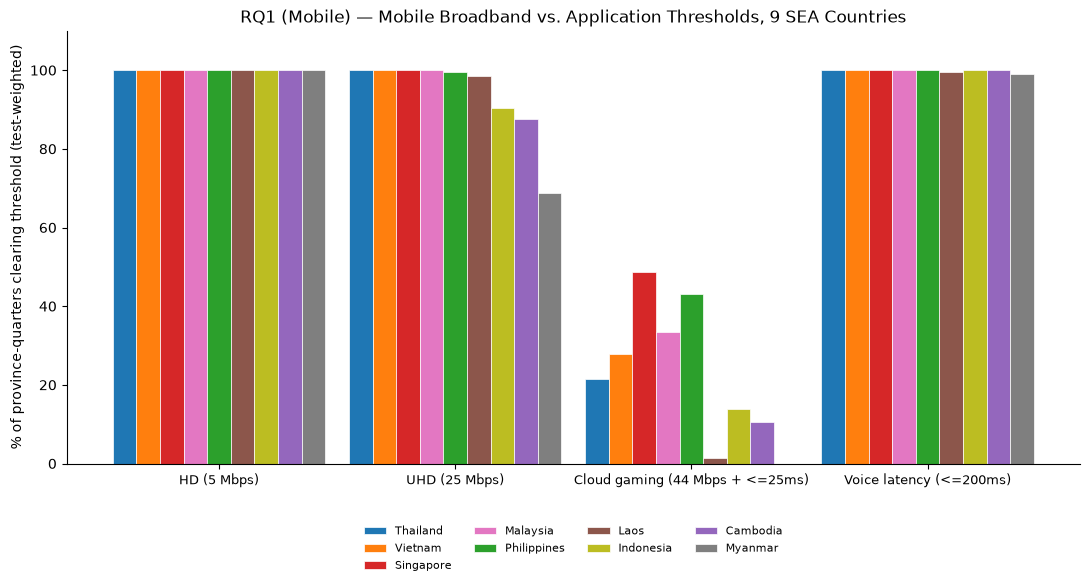

In [14]:
mobile_countries_order = mobile_pct.sort_values('UHD (25 Mbps)', ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metrics))
width = 0.1

for i, country in enumerate(mobile_countries_order):
    vals = mobile_pct.loc[country, metrics].values
    ax.bar(x + i * width, vals, width, label=country, color=COUNTRY_COLORS[country],
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width * (len(mobile_countries_order) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylabel('% of province-quarters clearing threshold (test-weighted)')
ax.set_ylim(0, 110)
ax.set_title('RQ1 (Mobile) — Mobile Broadband vs. Application Thresholds, 9 SEA Countries')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Fixed vs. mobile gap — same country, same threshold

Do cellular customers see meaningfully worse pass rates than fixed customers in the same
country? Compares each country's fixed vs. mobile UHD and cloud-gaming pass rate directly.

In [15]:
compare_fixed_mobile = pd.DataFrame({
    'Fixed UHD %': summary_pct['UHD (25 Mbps)'],
    'Mobile UHD %': mobile_pct['UHD (25 Mbps)'],
    'Fixed CloudGaming %': summary_pct['Cloud gaming (44 Mbps + <=25ms)'],
    'Mobile CloudGaming %': mobile_pct['Cloud gaming (44 Mbps + <=25ms)'],
}).round(1)
compare_fixed_mobile['UHD gap (fixed-mobile)'] = (compare_fixed_mobile['Fixed UHD %'] - compare_fixed_mobile['Mobile UHD %']).round(1)
compare_fixed_mobile['CloudGaming gap (fixed-mobile)'] = (compare_fixed_mobile['Fixed CloudGaming %'] - compare_fixed_mobile['Mobile CloudGaming %']).round(1)
compare_fixed_mobile.sort_values('UHD gap (fixed-mobile)', ascending=False)

,Fixed UHD %,Mobile UHD %,Fixed CloudGaming %,Mobile CloudGaming %,UHD gap (fixed-mobile),CloudGaming gap (fixed-mobile)
country,,,,,,
Cambodia,97.6,87.7,64.9,10.5,9.9,54.4
Laos,99.4,98.6,64.2,1.4,0.8,62.8
Philippines,100.0,99.6,92.6,43.2,0.4,49.4
Thailand,100.0,100.0,99.5,21.6,0.0,77.9
Vietnam,100.0,100.0,100.0,27.9,0.0,72.1
Singapore,100.0,100.0,100.0,48.8,0.0,51.2
Malaysia,100.0,100.0,97.6,33.5,0.0,64.1
Indonesia,88.1,90.5,35.6,13.9,-2.4,21.7
Myanmar,22.1,68.8,0.0,0.0,-46.7,0.0


### RQ1.2 (Mobile) — Capital City Comparison

Same `CAPITALS` mapping as the fixed-broadband section above, applied to mobile.

In [16]:
mobile_cap_mask = mobile_df.apply(lambda r: r['province'] == CAPITALS.get(r['country']), axis=1)
mobile_cap_df = mobile_df[mobile_cap_mask].copy()

mobile_cap_rows = []
for country in MOBILE_COUNTRIES:
    sub = mobile_cap_df[mobile_cap_df['country'] == country]
    row = {'country': country, 'n_tests_total': int(sub['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(sub, label)
    mobile_cap_rows.append(row)

mobile_cap_summary = pd.DataFrame(mobile_cap_rows).set_index('country')
mobile_cap_pct = (mobile_cap_summary[list(THRESH.keys())] * 100).round(1)
mobile_cap_pct['n_tests_total'] = mobile_cap_summary['n_tests_total']
mobile_cap_pct.sort_values('Cloud gaming (44 Mbps + <=25ms)', ascending=False)

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_tests_total
country,,,,,
Philippines,100.0,100.0,100.0,100.0,2026748
Malaysia,100.0,100.0,100.0,100.0,1073444
Indonesia,100.0,100.0,58.9,100.0,2177797
Thailand,100.0,100.0,51.3,100.0,2423786
Vietnam,100.0,100.0,38.1,100.0,563270
Cambodia,100.0,100.0,25.6,100.0,201329
Laos,100.0,100.0,7.4,100.0,96616
Singapore,100.0,100.0,0.0,100.0,341416
Myanmar,100.0,97.1,0.0,100.0,80482


## Key Findings (RQ1 + RQ1.2, mobile)

- **Cloud gaming is where mobile actually differs from fixed — badly, almost everywhere.** Every
  country that clears cloud-gaming at 100% on fixed collapses on mobile: Vietnam 100%→**27.9%**,
  Singapore 100%→**48.8%**, Malaysia 97.6%→**33.5%**, Thailand 99.5%→**21.6%**. The fixed-mobile
  gap is largest for exactly the countries with the best fixed networks (Thailand −77.9pp, Vietnam
  −72.1pp, Malaysia −64.1pp, Laos −62.8pp) — the 25ms latency floor, not the 44 Mbps throughput
  floor, is the binding constraint, and cellular RTT structurally can't match fixed FTTH here. Only
  Myanmar (already 0% on both) and Indonesia (13.9% mobile vs. 35.6% fixed, a comparatively small
  −21.7pp gap) don't show this pattern, because their fixed networks were already failing this
  threshold too.
- **UHD (25 Mbps) does *not* uniformly get worse on mobile — Myanmar inverts.** Most countries see
  UHD hold roughly steady or dip slightly on mobile (Laos 99.4%→98.6%, Cambodia 97.6%→87.7%), but
  **Myanmar's mobile UHD (68.8%) is more than 3x its fixed UHD (22.1%)** — the single largest
  fixed→mobile *improvement* in the dataset. This is surprising enough to flag rather than explain:
  plausibly Myanmar's cellular network was built/upgraded more recently than its fixed
  infrastructure, but this needs corroboration (e.g. NDT7 mobile, if sample size allows) before
  treating it as a real finding rather than a small-sample artifact — Myanmar mobile's
  `n_tests_total` (246,577) is the second-smallest in this comparison.
- **Capital-city mobile has its own inversion: Singapore's Central Region fails cloud gaming
  entirely (0%) despite the country's 48.8% national mobile pass rate** — the opposite of the
  usual "capital is at least as good" pattern, and a mobile-specific echo of the same
  capital-doesn't-always-win story already seen in Myanmar's fixed-broadband capital result
  (RQ1.2 Key Findings above). Philippines and Malaysia go the other way — both jump to **100%**
  mobile cloud-gaming in their capital despite mediocre national mobile rates (43.2%/33.5%),
  consistent with the fixed-broadband capital-premium pattern.
- **This is the concrete answer to the "not yet done" flag left in the fixed-broadband Key
  Findings above:** mobile is indeed where the real speed/latency-threshold variance lives —
  cloud gaming in particular is essentially a fixed-broadband-only capability across this entire
  region, not a mobile one, in 7 of 9 countries.
- **Limitation, same as fixed:** province-quarter test-weighted average, not per-test — see the
  fixed-broadband methodology note above; applies identically here.